In [ ]:
import kagglehub
import shutil
import os

# Download latest version
path = kagglehub.dataset_download("brsdincer/star-type-classification")

print("Path to dataset files:", path)


# Caminho de destino
dest_path = "/content/"

shutil.copytree(path, dest_path, dirs_exist_ok=True)

print(f"Dataset copiado para: {dest_path}")

Using Colab cache for faster access to the 'star-type-classification' dataset.
Path to dataset files: /kaggle/input/star-type-classification
Dataset copiado para: /content/


Source : [link - kaggle](https://www.kaggle.com/datasets/brsdincer/star-type-classification)

# Exploratory Data Analysis


In [ ]:
import pandas as pd

dataset = pd.read_csv("/content/Stars.csv")


dataset = dataset.rename(
    columns={
        "Temperature": "Temperature_K",
        "L": "Luminosity_Lo",
        "R": "Radius_Ro",
        "A_M": "Absolute_Magnitude",
        "Color": "Color_Name",
        "Spectral_Class": "Spectral_Class",
        "Type": "Star_Type",
    }
)


dataset.head()

,Temperature_K,Luminosity_Lo,Radius_Ro,Absolute_Magnitude,Color_Name,Spectral_Class,Star_Type
0,3068,0.002400,0.1700,16.12,Red,M,0
1,3042,0.000500,0.1542,16.60,Red,M,0
2,2600,0.000300,0.1020,18.70,Red,M,0
3,2800,0.000200,0.1600,16.65,Red,M,0
4,1939,0.000138,0.1030,20.06,Red,M,0


In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Temperature_K       240 non-null    int64  
 1   Luminosity_Lo       240 non-null    float64
 2   Radius_Ro           240 non-null    float64
 3   Absolute_Magnitude  240 non-null    float64
 4   Color_Name          240 non-null    object 
 5   Spectral_Class      240 non-null    object 
 6   Star_Type           240 non-null    int64  
dtypes: float64(3), int64(2), object(2)
memory usage: 13.3+ KB


In [ ]:
print(dataset.isna().sum())
print(dataset.isnull().sum())

print("shape:", dataset.shape)
dataset.describe()

Temperature_K         0
Luminosity_Lo         0
Radius_Ro             0
Absolute_Magnitude    0
Color_Name            0
Spectral_Class        0
Star_Type             0
dtype: int64
Temperature_K         0
Luminosity_Lo         0
Radius_Ro             0
Absolute_Magnitude    0
Color_Name            0
Spectral_Class        0
Star_Type             0
dtype: int64
shape: (240, 7)


,Temperature_K,Luminosity_Lo,Radius_Ro,Absolute_Magnitude,Star_Type
count,240.000000,240.000000,240.000000,240.000000,240.000000
mean,10497.462500,107188.361635,237.157781,4.382396,2.500000
std,9552.425037,179432.244940,517.155763,10.532512,1.711394
min,1939.000000,0.000080,0.008400,-11.920000,0.000000
25%,3344.250000,0.000865,0.102750,-6.232500,1.000000
50%,5776.000000,0.070500,0.762500,8.313000,2.500000
75%,15055.500000,198050.000000,42.750000,13.697500,4.000000
max,40000.000000,849420.000000,1948.500000,20.060000,5.000000


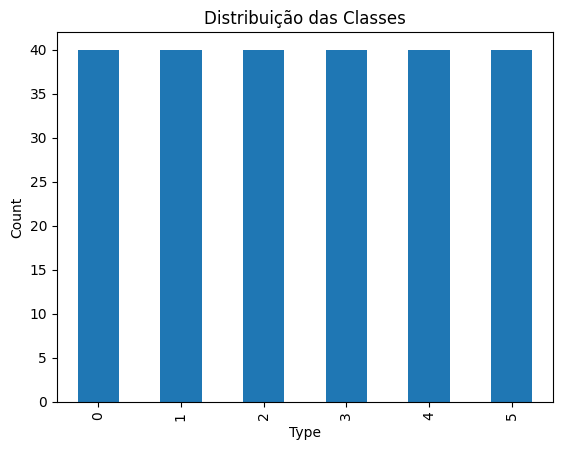

In [ ]:
dataset["Star_Type"].value_counts().sort_index().plot(kind="bar")
plt.xlabel("Type")
plt.ylabel("Count")
plt.title("Distribuição das Classes")
plt.show()


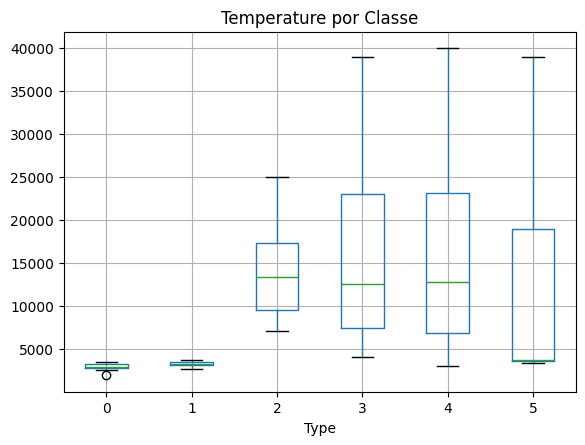

In [ ]:
dataset.boxplot(column="Temperature_K", by="Star_Type")
plt.title("Temperature por Classe")
plt.suptitle("")
plt.xlabel("Type")
plt.show()


In [ ]:
dataset.columns

Index(['Temperature_K', 'Luminosity_Lo', 'Radius_Ro', 'Absolute_Magnitude',
       'Color_Name', 'Spectral_Class', 'Star_Type'],
      dtype='object')

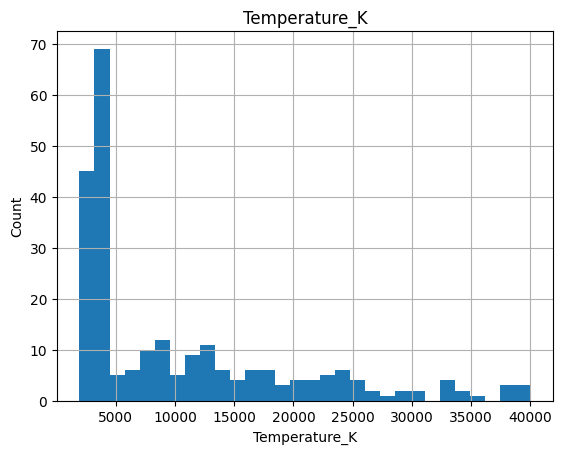

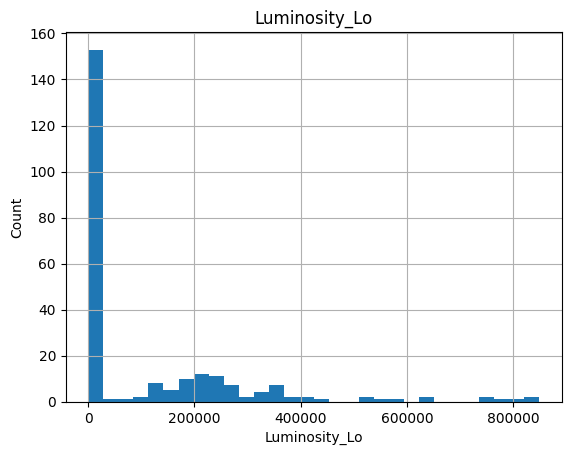

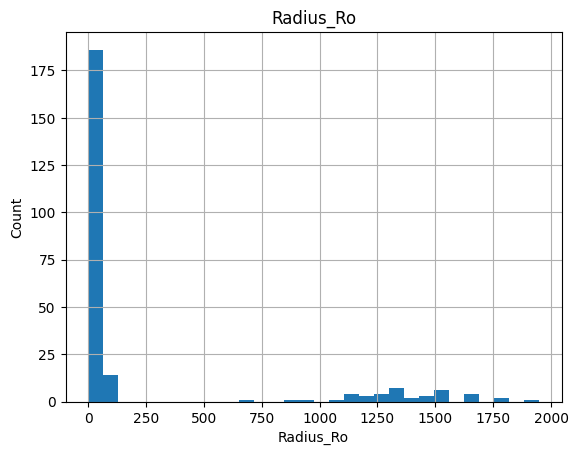

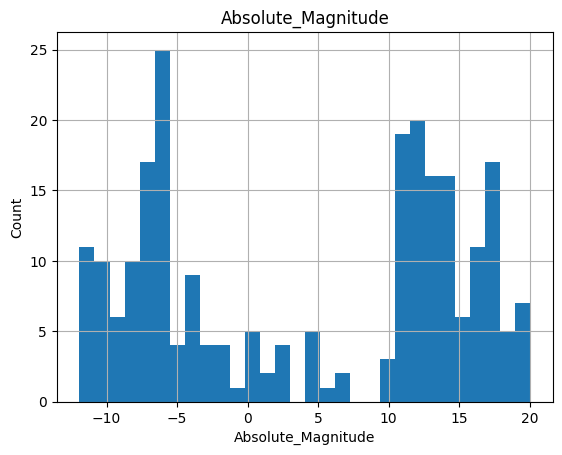

In [ ]:
num_cols = ['Temperature_K', 'Luminosity_Lo', 'Radius_Ro', 'Absolute_Magnitude']

for col in num_cols:
    dataset[col].hist(bins=30)
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()


# OneHotEncoder

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC

In [ ]:
X = dataset.drop(columns=["Star_Type"])
y = dataset["Star_Type"]

In [ ]:
y.value_counts()

,count
Star_Type,
0,40
1,40
2,40
3,40
4,40
5,40


In [ ]:
num_cols = ['Temperature_K', 'Luminosity_Lo', 'Radius_Ro', 'Absolute_Magnitude']
cat_cols = ["Color_Name", "Spectral_Class"]

In [ ]:
preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ],
    remainder="drop",
)

In [ ]:
model = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("svm", SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42)),
    ]
)

# Training

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [ ]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

acc = accuracy_score(y_test, y_pred)
print(f"Acuracia: {acc:.4f}")


Acuracia: 0.9583


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      1.00      0.92        12
           1       1.00      0.83      0.91        12
           2       1.00      1.00      1.00        12
           3       0.92      1.00      0.96        12
           4       1.00      0.92      0.96        12
           5       1.00      1.00      1.00        12

    accuracy                           0.96        72
   macro avg       0.96      0.96      0.96        72
weighted avg       0.96      0.96      0.96        72



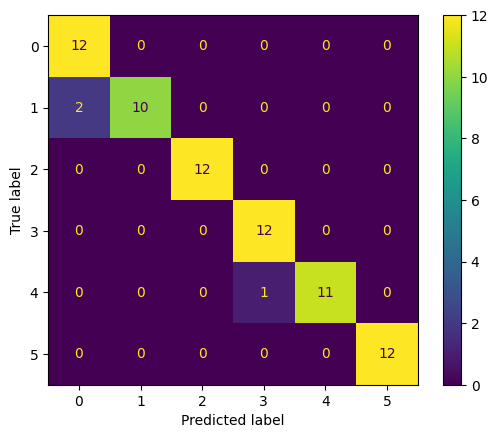

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()


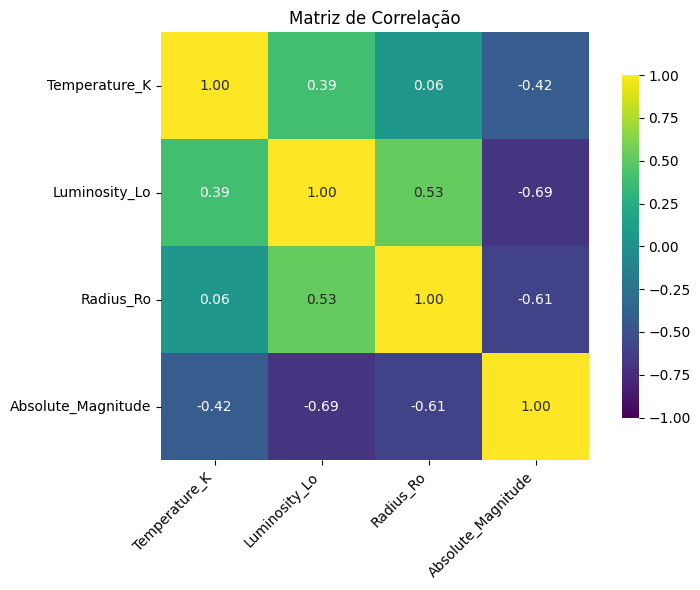

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt


corr = dataset[num_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    vmin=-1,
    vmax=1,
    square=True,
    cbar_kws={"shrink": 0.8}
)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.title("Matriz de Correlação")
plt.tight_layout()
plt.show()
